In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [5]:
# ─────────────────────────────────────────────
# 1. LOAD & RENAME
# ─────────────────────────────────────────────
df = pd.read_csv("clean_df.csv")

df = df.rename(columns={
    'ft':                 'fuel_type',
    'bt':                 'body_type',
    'km':                 'kms_driven',
    'oem':                'model',
    'modelYear':          'model_year',
    'Insurance Validity': 'insurance_validity',
    'Mileage':            'mileage',
})

print("Shape:", df.shape)
print(df.head(2))

Shape: (8369, 11)
        city fuel_type  body_type  kms_driven transmission      owner   model  \
0  Bangalore    Petrol  Hatchback      120000       Manual  3rd Owner  Maruti   
1  Bangalore    Petrol        SUV       32706       Manual  2nd Owner    Ford   

   model_year   price insurance_validity  mileage  
0        2015  400000        Third Party     23.1  
1        2018  811000      Comprehensive     17.0  


In [7]:
# ─────────────────────────────────────────────
# 2. BASIC CLEANING
# ─────────────────────────────────────────────
print("\nNull counts:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Shape after dedup:", df.shape)

# Extract numeric owner count  (e.g. "1st Owner" → 1)
df['owner'] = df['owner'].str.extract(r'(\d+)').astype(int)


Null counts:
 city                  0
fuel_type             0
body_type             0
kms_driven            0
transmission          0
owner                 0
model                 0
model_year            0
price                 0
insurance_validity    0
mileage               0
dtype: int64

Duplicates: 116
Shape after dedup: (8253, 11)


In [9]:
# ─────────────────────────────────────────────
# 3. ENCODE CATEGORICALS
#    Use OrdinalEncoder so each column keeps its
#    own mapping — avoids the shared-LabelEncoder
#    data-leakage bug.
# ─────────────────────────────────────────────
object_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical columns:", object_cols)

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[object_cols] = enc.fit_transform(df[object_cols])

print(df.info())


Categorical columns: ['city', 'fuel_type', 'body_type', 'transmission', 'model', 'insurance_validity']
<class 'pandas.core.frame.DataFrame'>
Index: 8253 entries, 0 to 8368
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                8253 non-null   float64
 1   fuel_type           8253 non-null   float64
 2   body_type           8253 non-null   float64
 3   kms_driven          8253 non-null   int64  
 4   transmission        8253 non-null   float64
 5   owner               8253 non-null   int32  
 6   model               8253 non-null   float64
 7   model_year          8253 non-null   int64  
 8   price               8253 non-null   int64  
 9   insurance_validity  8253 non-null   float64
 10  mileage             8253 non-null   float64
dtypes: float64(7), int32(1), int64(3)
memory usage: 741.5 KB
None


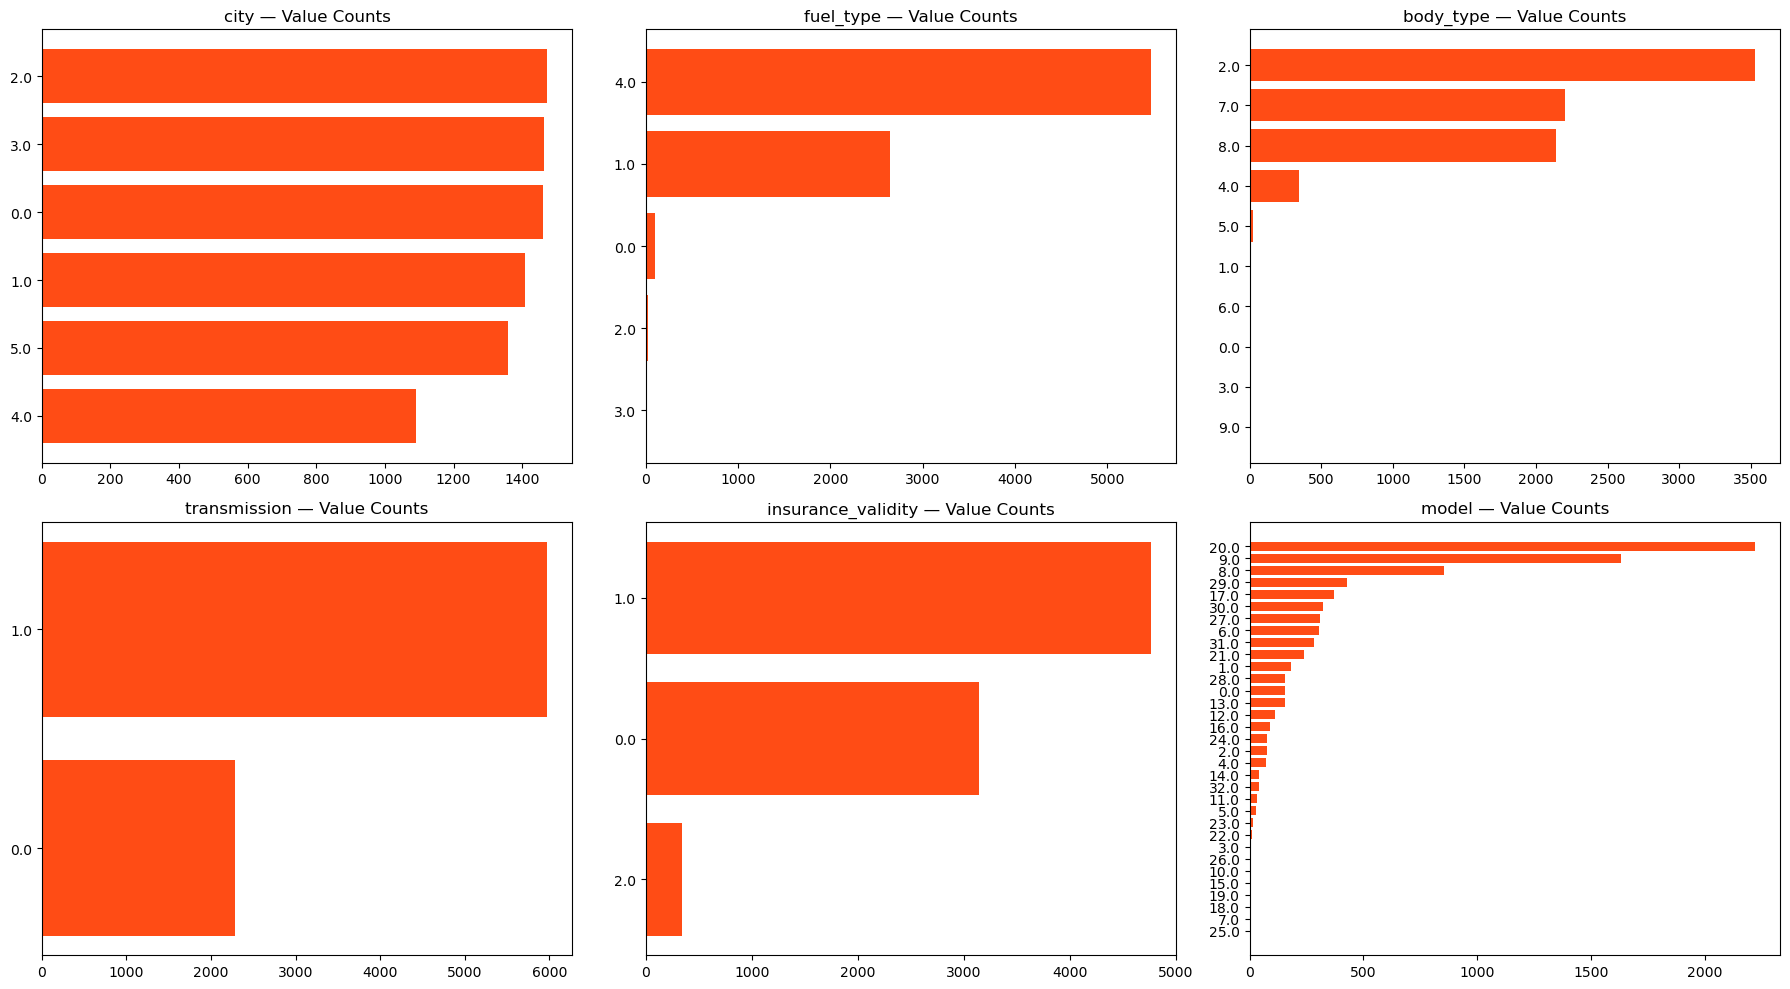

In [29]:
cat_cols = ['city', 'fuel_type', 'body_type', 'transmission',
            'insurance_validity', 'model']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index.astype(str), counts.values, color='#ff4c15')
    axes[i].set_title(f"{col} — Value Counts")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

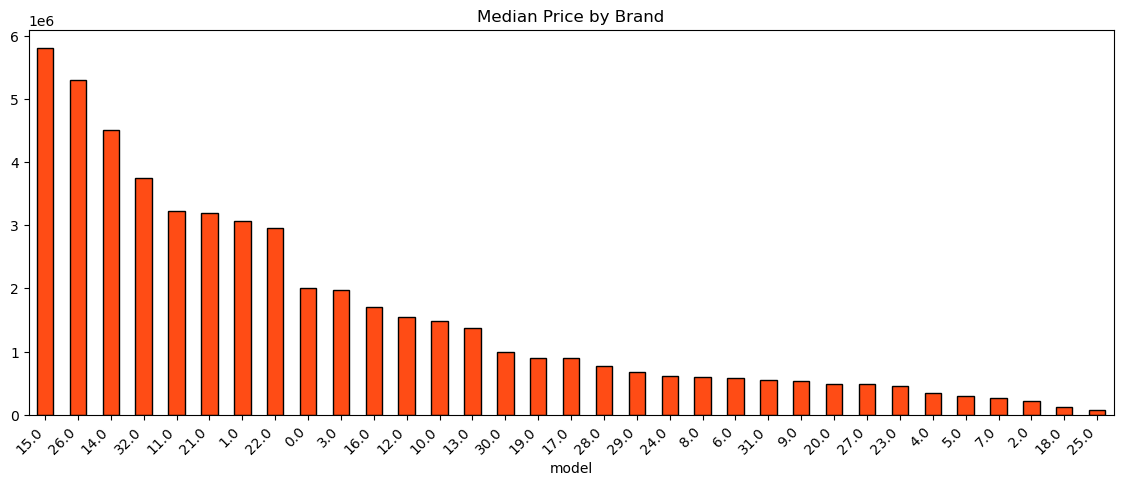

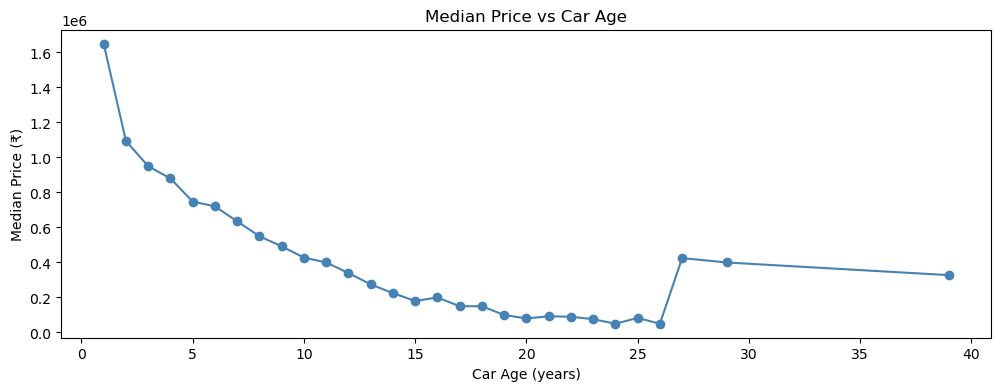

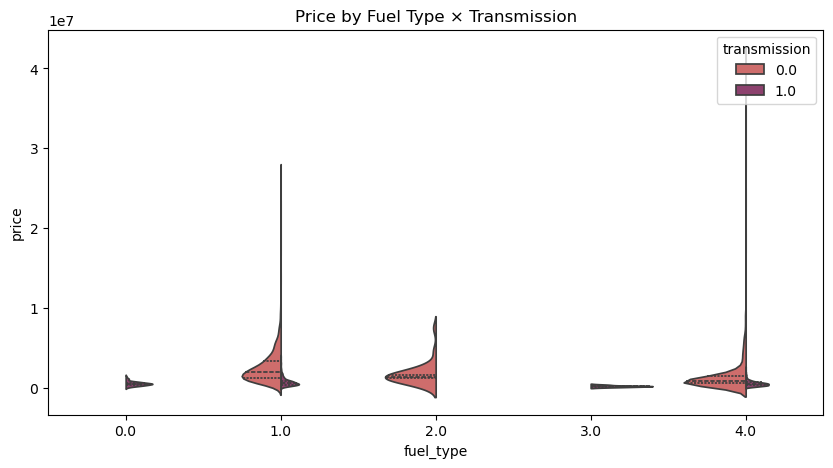

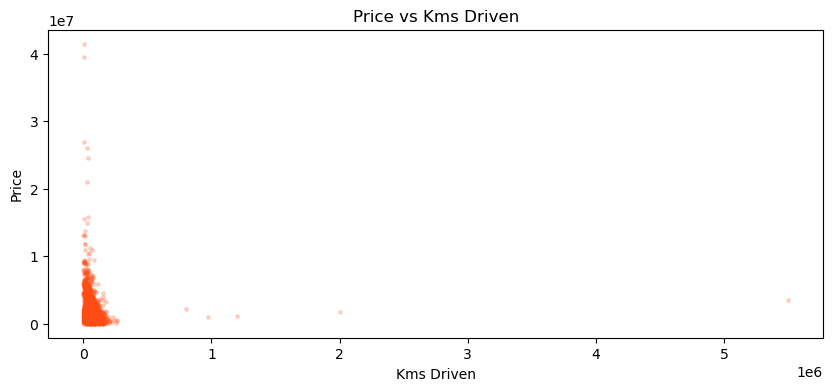

In [25]:
# 1. Average price by brand
brand_price = df.groupby('model')['price'].median().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
brand_price.plot(kind='bar', color='#ff4c15', edgecolor='black')
plt.title("Median Price by Brand")
plt.xticks(rotation=45, ha='right')
plt.show()

# 2. Price depreciation by car age
df['car_age'] = 2024 - df['model_year']
age_price = df.groupby('car_age')['price'].median()
plt.figure(figsize=(12, 4))
age_price.plot(marker='o', color='steelblue')
plt.title("Median Price vs Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Median Price (₹)")
plt.show()

# 3. Price by fuel type and transmission (combined)
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='fuel_type', y='price', hue='transmission',
               split=True, palette='flare', inner='quartile')
plt.title("Price by Fuel Type × Transmission")
plt.show()

# 4. Price vs kms_driven — does it drop linearly?
plt.figure(figsize=(10, 4))
plt.scatter(df['kms_driven'], df['price'], alpha=0.2, s=6, color='#ff4c15')
plt.title("Price vs Kms Driven")
plt.xlabel("Kms Driven")
plt.ylabel("Price")
plt.show()

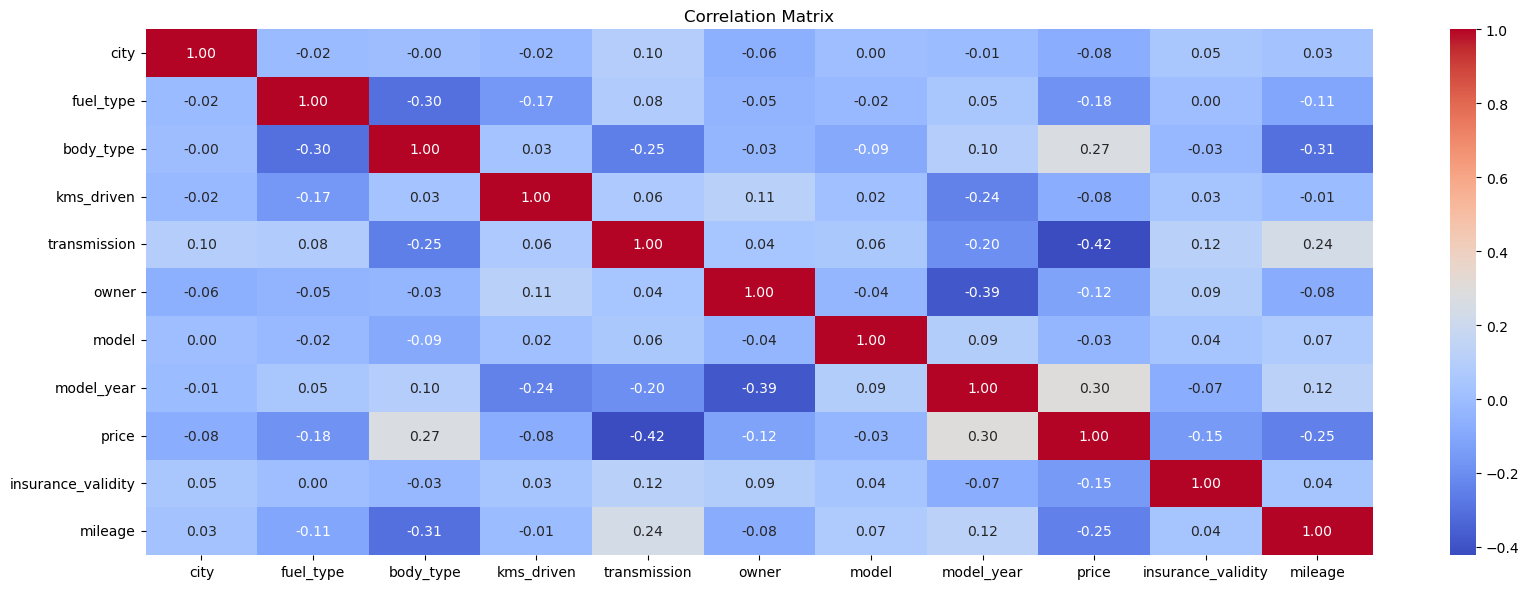

In [11]:
# ─────────────────────────────────────────────
# 4. CORRELATION HEATMAP
# ─────────────────────────────────────────────
plt.figure(figsize=(17, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
# ─────────────────────────────────────────────
# 5. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

X_train: (6602, 10)  |  X_test: (1651, 10)


In [15]:
# ─────────────────────────────────────────────
# 6. SCALE FEATURES
#    Distance-based (KNN) and regularised linear
#    models are sensitive to feature scale.
#    Tree / boosting models are not, but scaling
#    doesn't hurt them either.
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)

In [17]:
# ─────────────────────────────────────────────
# 7. MODELS
# ─────────────────────────────────────────────
models = [
    ('Random Forest',
     RandomForestRegressor(n_estimators=500, max_depth=15,
                           min_samples_split=5, min_samples_leaf=2,
                           random_state=42)),
    ('Linear Regression',
     LinearRegression()),
    ('Decision Tree',DecisionTreeRegressor(
    max_depth=4,          # already 6, try 4–5
    min_samples_leaf=10,  # was 2 by default, increase this
    min_samples_split=20,
    ccp_alpha=0.001,      # cost-complexity pruning — add this
)),
    ('KNN',
     KNeighborsRegressor(n_neighbors=3, metric='manhattan')),
    ('Gradient Boosting',GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,           # reduce from 5 → 4
    min_samples_leaf=10,   # increase from 5 → 10
    subsample=0.7,         # reduce from 0.8 → 0.7
    max_features=0.8,      # add this — only use 80% of features per split
)),
    ('XGBoost',
     XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=0.5,         # increase L1
    reg_lambda=3.0,        # increase L2
    min_child_weight=8,    # increase from 5 → 8
    gamma=0.1,             # add this — minimum loss reduction to split
)),
]

In [19]:
# ─────────────────────────────────────────────
# 8. TRAIN, EVALUATE, COLLECT RESULTS  (single loop)
# ─────────────────────────────────────────────
# KNN and Linear Regression benefit from scaled data;
# tree-based models use raw data.
SCALED_MODELS = {'KNN', 'Linear Regression'}

records = []

for name, model in models:
    if name in SCALED_MODELS:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train.values, X_test.values

    model.fit(Xtr, y_train)
    train_pred = model.predict(Xtr)
    test_pred  = model.predict(Xte)

    rec = {
        "Model":       name,
        "MSE Train":   mean_squared_error(y_train, train_pred),
        "MSE Test":    mean_squared_error(y_test,  test_pred),
        "MAE Train":   mean_absolute_error(y_train, train_pred),
        "MAE Test":    mean_absolute_error(y_test,  test_pred),
        "R2 Train (%)": r2_score(y_train, train_pred) * 100,
        "R2 Test (%)":  r2_score(y_test,  test_pred)  * 100,
    }
    records.append(rec)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MSE   — Train: {rec['MSE Train']:>15,.2f}  |  Test: {rec['MSE Test']:>15,.2f}")
    print(f"  MAE   — Train: {rec['MAE Train']:>15,.2f}  |  Test: {rec['MAE Test']:>15,.2f}")
    print(f"  R²    — Train: {rec['R2 Train (%)']:>14.2f}%  |  Test: {rec['R2 Test (%)']:>14.2f}%")

results_df = pd.DataFrame(records)
print("\n", results_df.to_string(index=False))


  Random Forest
  MSE   — Train: 288,289,267,920.63  |  Test: 752,087,948,564.39
  MAE   — Train:      126,430.70  |  Test:      230,323.77
  R²    — Train:          85.46%  |  Test:          64.81%

  Linear Regression
  MSE   — Train: 1,373,235,474,873.47  |  Test: 1,410,431,308,369.79
  MAE   — Train:      483,180.71  |  Test:      512,398.47
  R²    — Train:          30.72%  |  Test:          34.00%

  Decision Tree
  MSE   — Train: 1,183,938,717,008.77  |  Test: 1,486,709,934,658.89
  MAE   — Train:      429,555.86  |  Test:      449,690.43
  R²    — Train:          40.27%  |  Test:          30.43%

  KNN
  MSE   — Train: 412,416,825,459.68  |  Test: 1,045,040,272,055.61
  MAE   — Train:      189,576.69  |  Test:      294,406.59
  R²    — Train:          79.19%  |  Test:          51.10%

  Gradient Boosting
  MSE   — Train: 256,110,815,737.71  |  Test: 774,943,514,298.85
  MAE   — Train:      209,112.50  |  Test:      265,398.23
  R²    — Train:          87.08%  |  Test:         

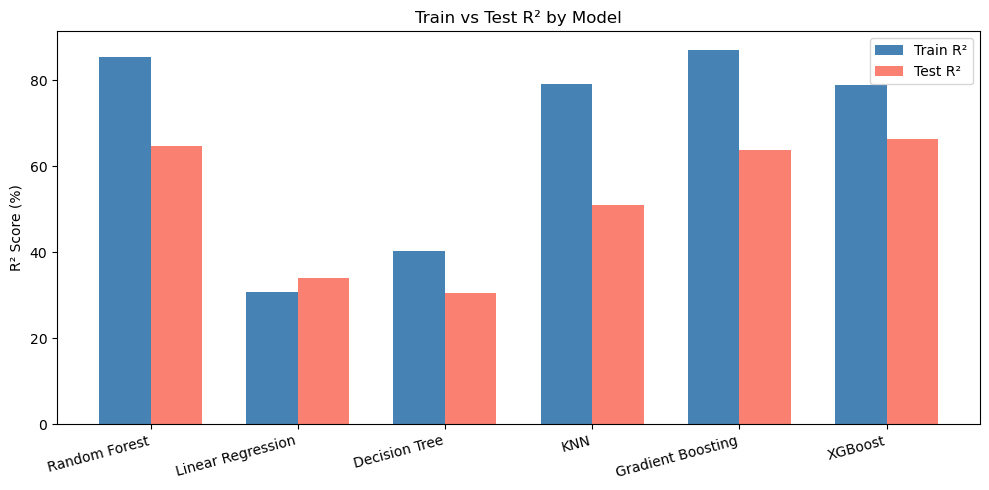

In [21]:
# ─────────────────────────────────────────────
# 9. VISUALISE R² COMPARISON
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(results_df))
width = 0.35

ax.bar(x_pos - width/2, results_df["R2 Train (%)"], width, label="Train R²", color='steelblue')
ax.bar(x_pos + width/2, results_df["R2 Test (%)"],  width, label="Test R²",  color='salmon')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df["Model"], rotation=15, ha='right')
ax.set_ylabel("R² Score (%)")
ax.set_title("Train vs Test R² by Model")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# ─────────────────────────────────────────────
# 10. SAVE BEST MODEL + SCALER
# ─────────────────────────────────────────────
best_row   = results_df.loc[results_df["R2 Test (%)"].idxmax()]
best_name  = best_row["Model"]
best_model = dict(models)[best_name]

print(f"\nBest model: {best_name}  (Test R² = {best_row['R2 Test (%)']:.2f}%)")

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved best_model.pkl and scaler.pkl")

from sklearn.model_selection import cross_val_score
scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f"CV R²: {scores.mean():.3f} ± {scores.std():.3f}")


Best model: XGBoost  (Test R² = 66.26%)
Saved best_model.pkl and scaler.pkl
CV R²: 0.621 ± 0.107
